Comparação visual: Gradient Centralization (GC)

CIFAR-10 + ResNet18 + SGD

Mostra as curvas de loss/accuracy com GC LIGADO e DESLIGADO

In [1]:
!pip -q install torch torchvision tqdm matplotlib --extra-index-url https://download.pytorch.org/whl/cu121

In [2]:
# ========== IMPORTAÇÕES ==========
# Bibliotecas principais para deep learning e manipulação de dados
import time, torch, torch.nn as nn, torch.optim as optim
from torch.optim import lr_scheduler        # Scheduler para ajustar taxa de aprendizagem
from torch.utils.data import DataLoader      # Carregador de dados em batches
import torchvision                           # Biblioteca para visão computacional
import torchvision.transforms as T           # Transformações de imagens (augmentação)
from torchvision.models import resnet18      # Modelo ResNet-18 pré-definido
from tqdm.auto import tqdm                   # Barra de progresso (opcional)
import matplotlib.pyplot as plt              # Biblioteca para plotar gráficos

# ========== CONFIGURAÇÃO DO DISPOSITIVO ==========
# Detecta automaticamente se GPU está disponível, senão usa CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

Device: cuda


In [3]:
# ---------- Hiperparâmetros ----------
# Configuração dos parâmetros de treinamento
epochs = 100              # Número total de épocas de treinamento
batch_size = 128          # Tamanho do batch (quantas imagens processar por vez)
base_lr = 0.1             # Taxa de aprendizagem inicial (learning rate)
momentum = 0.9            # Momentum para o otimizador SGD (ajuda na convergência)
weight_decay = 5e-4       # Regularização L2 (previne overfitting)
num_workers = 0           # Número de processos paralelos para carregar dados
pin_memory = torch.cuda.is_available()  # Acelera transferência CPU->GPU se tiver GPU

if torch.cuda.is_available():
    # Otimização: permite que cuDNN escolha algoritmos mais rápidos
    torch.backends.cudnn.benchmark = True

In [4]:
# ---------- Conjunto de dados ----------
# ========== PREPROCESSAMENTO DE DADOS ==========
# Valores de normalização específicos do CIFAR-10 (calculados do dataset completo)
mean, std = (0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)

# Transformações para TREINAMENTO (com augmentação de dados)
train_tf = T.Compose([
    T.RandomCrop(32, padding=4),    # Corte aleatório com padding (augmentação)
    T.RandomHorizontalFlip(),       # Espelhamento horizontal aleatório
    T.ToTensor(),                   # Converte PIL Image para tensor PyTorch
    T.Normalize(mean, std)          # Normaliza usando média e desvio padrão do CIFAR-10
])

# Transformações para TESTE (sem augmentação, só normalização)
test_tf = T.Compose([
    T.ToTensor(),                   # Converte para tensor
    T.Normalize(mean, std)          # Normaliza da mesma forma que o treinamento
])

# ========== CARREGAMENTO DOS DATASETS ==========
# CIFAR-10: 60.000 imagens 32x32 em 10 classes (avião, carro, pássaro, gato, etc.)
train_ds = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=train_tf)
test_ds = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_tf)

# ========== CRIAÇÃO DOS DATALOADERS ==========
# DataLoader: organiza dados em batches e permite iteração eficiente
train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,      # Processa 128 imagens por vez
    shuffle=True,               # Embaralha dados a cada época (importante!)
    num_workers=num_workers,    # Processos paralelos para carregar dados
    pin_memory=pin_memory       # Acelera transferência para GPU
)
test_loader = DataLoader(
    test_ds,
    batch_size=batch_size,      # Mesmo tamanho de batch
    shuffle=False,              # Não embaralha teste (não é necessário)
    num_workers=num_workers,
    pin_memory=pin_memory
)

100%|██████████| 170M/170M [00:03<00:00, 42.7MB/s]


O QUE É GC?
* Técnica que centraliza os gradientes subtraindo sua média
* Melhora a convergência e estabilidade do treinamento
* Funciona especialmente bem em camadas convolucionais e lineares



  COMO FUNCIONA?
    - Para cada parâmetro com gradiente multi-dimensional:
    1. Calcula a média do gradiente ao longo das dimensões de entrada
    2. Subtrai essa média do gradiente original (centralização)
    - Isso reduz a variância dos gradientes e melhora a otimização

In [5]:
# ---------- Funções ----------
# ========== GRADIENT CENTRALIZATION (GC) ==========
@torch.no_grad()
def apply_gradient_centralization_(model: nn.Module):
    """
    Aplica Gradient Centralization (GC) nos gradientes do modelo.
    """
    for p in model.parameters():
        if p.grad is None: continue          # Pula parâmetros sem gradiente
        if p.grad.dim() > 1:                 # Aplica apenas em tensores multi-dimensionais
            # Calcula dimensões para redução (todas exceto a primeira)
            dims = tuple(range(1, p.grad.dim()))
            # Subtrai a média do gradiente (centralização in-place)
            p.grad.sub_(p.grad.mean(dim=dims, keepdim=True))

In [6]:
# ========== FUNÇÃO DE ACURÁCIA ==========
def accuracy(logits, y):
    """
    Calcula a acurácia retornando (acertos, total).
    """
    with torch.no_grad():                    # Não calcula gradientes (mais eficiente)
        preds = logits.argmax(dim=1)         # Pega classe com maior probabilidade
        return (preds == y).sum().item(), preds.numel()  # Conta acertos e total

In [7]:

# ========== FUNÇÃO PRINCIPAL DE TREINAMENTO ==========
def train_eval(model, optimizer, scheduler, criterion, use_gc=False):
    """
    Args:
        model: Rede neural (ResNet18)
        optimizer: Otimizador (SGD)
        scheduler: Agendador de learning rate
        criterion: Função de perda (CrossEntropyLoss)
        use_gc: Se True, aplica Gradient Centralization

    Returns:
        dict: Histórico com loss e accuracy de treino e validação
    """
    # Dicionário para armazenar métricas de cada época
    history = {"tr_loss": [], "va_loss": [], "tr_acc": [], "va_acc": []}

    # ========== LOOP PRINCIPAL DE ÉPOCAS ==========
    for ep in range(1, epochs+1):
        # ---- FASE DE TREINAMENTO ----
        model.train()                        # Coloca modelo em modo treinamento
        train_loss, train_corr, train_total = 0.0, 0, 0

        # Loop pelos batches de treinamento
        for xb, yb in train_loader:
            # Move dados para GPU/CPU conforme dispositivo disponível
            xb, yb = xb.to(device), yb.to(device)

            # === PASSO DE TREINAMENTO ===
            optimizer.zero_grad(set_to_none=True)    # Zera gradientes (mais eficiente)
            logits = model(xb)                       # Forward pass: calcula predições
            loss = criterion(logits, yb)             # Calcula perda (cross-entropy)
            loss.backward()                          # Backward pass: calcula gradientes

            if use_gc:
                # Aplica Gradient Centralization antes de atualizar parâmetros
                apply_gradient_centralization_(model)

            optimizer.step()                         # Atualiza parâmetros do modelo

            # Acumula estatísticas para esta época
            corr, n = accuracy(logits, yb)           # Calcula acertos neste batch
            train_loss += loss.item() * n            # Acumula perda ponderada
            train_corr += corr                       # Acumula acertos
            train_total += n                         # Acumula total de amostras

        # Atualiza learning rate conforme agendamento
        scheduler.step()

        # Calcula métricas médias desta época
        tr_loss = train_loss / train_total       # Loss médio de treinamento
        tr_acc  = train_corr / train_total       # Acurácia de treinamento
        history["tr_loss"].append(tr_loss)
        history["tr_acc"].append(tr_acc)

        # ---- FASE DE VALIDAÇÃO ----
        model.eval()                             # Coloca modelo em modo avaliação
        val_loss, val_corr, val_total = 0.0, 0, 0

        with torch.no_grad():                    # Não calcula gradientes (economiza memória)
            for xb, yb in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                loss = criterion(logits, yb)
                corr, n = accuracy(logits, yb)
                val_loss += loss.item() * n
                val_corr += corr
                val_total += n

        va_loss = val_loss / val_total
        va_acc  = val_corr / val_total
        history["va_loss"].append(va_loss)
        history["va_acc"].append(va_acc)

        print(f"Ep {ep:02d} GC={use_gc} | "
            f"Train: acc {100*tr_acc:5.2f}%  loss {tr_loss:.4f} | "
            f"Val:   acc {100*va_acc:5.2f}%  loss {va_loss:.4f}")
    return history

# ---------- Treinamentos ----------
def get_model_optimizer():
    """Cria o modelo ResNet18 e configura otimizador SGD com scheduler."""
    model = resnet18(num_classes=10).to(device)
    opt = optim.SGD(model.parameters(), lr=base_lr, momentum=momentum, weight_decay=weight_decay)
    sch = lr_scheduler.MultiStepLR(opt, milestones=[epochs//2, int(epochs*0.8)], gamma=0.1)
    return model, opt, sch


def evaluate(model: nn.Module, loader: DataLoader, criterion: nn.Module, device=device):
    """Avalia o modelo no conjunto de dados e retorna loss e acurácia médios."""
    model.eval()
    total_loss, total_corr, total_n = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = criterion(logits, yb)
        corr, n = accuracy(logits, yb)  # função já definida acima
        total_loss += loss.item() * n
        total_corr += corr
        total_n    += n
    avg_loss = total_loss / total_n
    avg_acc  = total_corr / total_n
    return avg_loss, avg_acc

In [8]:
# ========== EXECUÇÃO DOS EXPERIMENTOS ==========
# Função de perda: Cross-Entropy (padrão para classificação multi-classe)
criterion = nn.CrossEntropyLoss()

# === EXPERIMENTO 1: TREINAMENTO SEM GRADIENT CENTRALIZATION ===
print(" EXPERIMENTO 1: Treinando SEM Gradient Centralization")
model_no_gc, opt, sch = get_model_optimizer()
hist_no_gc = train_eval(model_no_gc, opt, sch, criterion, use_gc=False)

# === EXPERIMENTO 2: TREINAMENTO COM GRADIENT CENTRALIZATION ===
print(" EXPERIMENTO 2: Treinando COM Gradient Centralization")
model_gc, opt, sch = get_model_optimizer()
hist_gc = train_eval(model_gc, opt, sch, criterion, use_gc=True)

 EXPERIMENTO 1: Treinando SEM Gradient Centralization
Ep 01 GC=False | Train: acc 32.79%  loss 1.9650 | Val:   acc 45.04%  loss 1.5906
Ep 02 GC=False | Train: acc 46.99%  loss 1.4480 | Val:   acc 54.31%  loss 1.2673
Ep 03 GC=False | Train: acc 55.21%  loss 1.2466 | Val:   acc 60.54%  loss 1.1133
Ep 04 GC=False | Train: acc 60.48%  loss 1.1105 | Val:   acc 60.53%  loss 1.1618
Ep 05 GC=False | Train: acc 64.37%  loss 1.0147 | Val:   acc 65.69%  loss 1.0099
Ep 06 GC=False | Train: acc 66.53%  loss 0.9540 | Val:   acc 69.37%  loss 0.8865
Ep 07 GC=False | Train: acc 68.57%  loss 0.9051 | Val:   acc 69.22%  loss 0.9031
Ep 08 GC=False | Train: acc 69.93%  loss 0.8659 | Val:   acc 66.79%  loss 0.9678
Ep 09 GC=False | Train: acc 70.69%  loss 0.8489 | Val:   acc 71.79%  loss 0.8052
Ep 10 GC=False | Train: acc 71.69%  loss 0.8229 | Val:   acc 68.66%  loss 0.9207
Ep 11 GC=False | Train: acc 72.22%  loss 0.8071 | Val:   acc 68.92%  loss 0.9099
Ep 12 GC=False | Train: acc 73.29%  loss 0.7777 | Val: 

In [9]:
# ========== AVALIAÇÃO FINAL DOS MODELOS ==========
print(" RESULTADOS FINAIS NO CONJUNTO DE TESTE")

# Avalia modelo treinado SEM Gradient Centralization
test_loss_no_gc, test_acc_no_gc = evaluate(model_no_gc, test_loader, criterion, device)
print(f" SEM GC -> loss: {test_loss_no_gc:.4f} | accuracy: {test_acc_no_gc:.4f} ({100*test_acc_no_gc:.2f}%)")

# Avalia modelo treinado COM Gradient Centralization
test_loss_gc, test_acc_gc = evaluate(model_gc, test_loader, criterion, device)
print(f" COM GC -> loss: {test_loss_gc:.4f} | accuracy: {test_acc_gc:.4f} ({100*test_acc_gc:.2f}%)")

# Calcula melhoria obtida com GC
improvement = (test_acc_gc - test_acc_no_gc) * 100
print(f"\n Melhoria com GC: {improvement:+.2f} pontos percentuais")

 RESULTADOS FINAIS NO CONJUNTO DE TESTE
 SEM GC -> loss: 0.4326 | accuracy: 0.8752 (87.52%)
 COM GC -> loss: 0.4158 | accuracy: 0.8813 (88.13%)

 Melhoria com GC: +0.61 pontos percentuais


GERANDO GRÁFICOS COMPARATIVOS


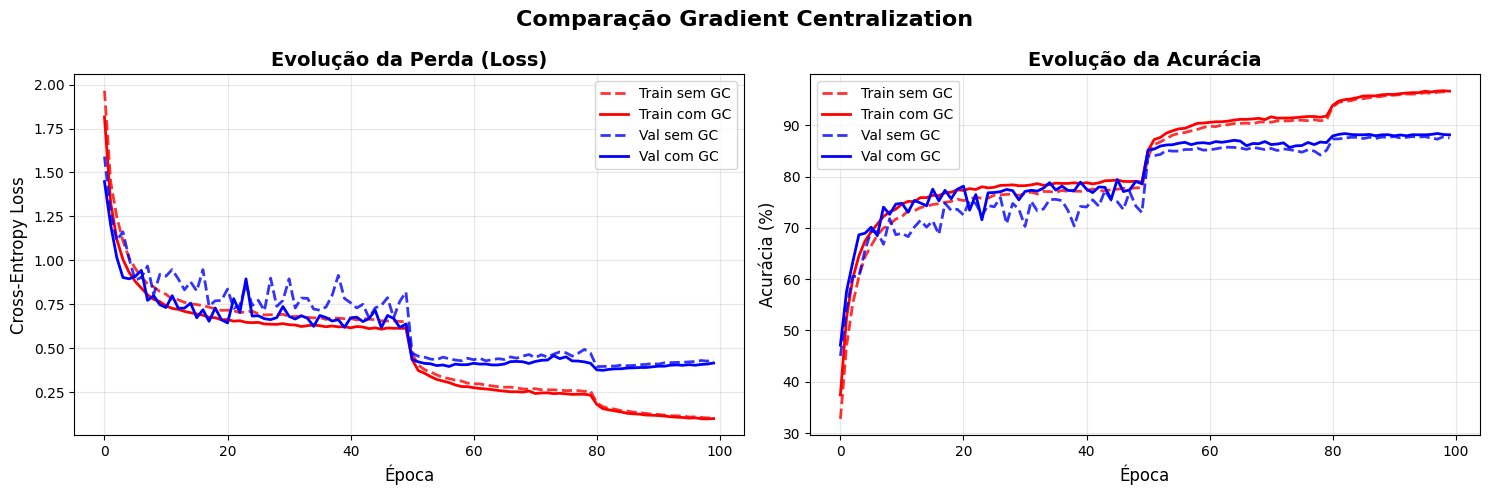

In [10]:
# ========== VISUALIZAÇÃO DOS RESULTADOS ==========
print("GERANDO GRÁFICOS COMPARATIVOS")

# Cria figura com 2 subplots lado a lado
plt.figure(figsize=(15,5))

# === GRÁFICO 1: CURVAS DE PERDA (LOSS) ===
plt.subplot(1,2,1)
plt.plot(hist_no_gc["tr_loss"], 'r--', linewidth=2, alpha=0.8, label="Train sem GC")
plt.plot(hist_gc["tr_loss"], 'r-', linewidth=2, label="Train com GC")
plt.plot(hist_no_gc["va_loss"], 'b--', linewidth=2, alpha=0.8, label="Val sem GC")
plt.plot(hist_gc["va_loss"], 'b-', linewidth=2, label="Val com GC")
plt.title("Evolução da Perda (Loss)", fontsize=14, fontweight='bold')
plt.xlabel("Época", fontsize=12)
plt.ylabel("Cross-Entropy Loss", fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

# === GRÁFICO 2: CURVAS DE ACURÁCIA ===
plt.subplot(1,2,2)
plt.plot([x*100 for x in hist_no_gc["tr_acc"]], 'r--', linewidth=2, alpha=0.8, label="Train sem GC")
plt.plot([x*100 for x in hist_gc["tr_acc"]], 'r-', linewidth=2, label="Train com GC")
plt.plot([x*100 for x in hist_no_gc["va_acc"]], 'b--', linewidth=2, alpha=0.8, label="Val sem GC")
plt.plot([x*100 for x in hist_gc["va_acc"]], 'b-', linewidth=2, label="Val com GC")
plt.title("Evolução da Acurácia", fontsize=14, fontweight='bold')
plt.xlabel("Época", fontsize=12)
plt.ylabel("Acurácia (%)", fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

# Título principal dos gráficos
plt.suptitle("Comparação Gradient Centralization", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

